### What this notebook does
1. Load and map attack labels to 5 classes (Normal, DoS, Probe, R2L, U2R)
2. Outlier detection with Isolation Forest
3. Log-transform skewed columns
4. Engineer new interaction features
5. Encode categorical features (One-Hot + frequency encoding)
6. Remove highly correlated features
7. Scale with RobustScaler
8. Balance classes with SMOTE
9. Save the processed dataset

## Imports & Configuration

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
import joblib

warnings.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_palette("husl")

SEED = 42
DATA_DIR = "data"
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

COLUMNS = [
    "duration", "protocol_type", "service", "flag",
    "src_bytes", "dst_bytes", "land", "wrong_fragment", "urgent", "hot",
    "num_failed_logins", "logged_in", "num_compromised", "root_shell",
    "su_attempted", "num_root", "num_file_creations", "num_shells",
    "num_access_files", "num_outbound_cmds", "is_host_login", "is_guest_login",
    "count", "srv_count", "serror_rate", "srv_serror_rate", "rerror_rate",
    "srv_rerror_rate", "same_srv_rate", "diff_srv_rate", "srv_diff_host_rate",
    "dst_host_count", "dst_host_srv_count", "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate",
    "dst_host_srv_serror_rate", "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate", "label", "difficulty_level"
]

print("Setup complete")

Setup complete


## Load Raw Data

In [2]:
train_path = os.path.join(DATA_DIR, "KDDTrain+.txt")
test_path  = os.path.join(DATA_DIR, "KDDTest+.txt")

df_train = pd.read_csv(train_path, header=None, names=COLUMNS)
df_test  = pd.read_csv(test_path,  header=None, names=COLUMNS)

print(f"Training set : {df_train.shape[0]:,} rows × {df_train.shape[1]} columns")
print(f"Test set     : {df_test.shape[0]:,}  rows × {df_test.shape[1]} columns")

Training set : 125,973 rows × 43 columns
Test set     : 22,544  rows × 43 columns


## Mapping Attacks

In [3]:
ATTACK_MAPPING = {
    "normal": "normal",
    # DoS
    "back": "DoS", "land": "DoS", "neptune": "DoS", "pod": "DoS",
    "smurf": "DoS", "teardrop": "DoS", "mailbomb": "DoS",
    "apache2": "DoS", "processtable": "DoS", "udpstorm": "DoS",
    # Probe
    "satan": "Probe", "ipsweep": "Probe", "nmap": "Probe",
    "portsweep": "Probe", "mscan": "Probe", "saint": "Probe",
    # R2L
    "guess_passwd": "R2L", "ftp_write": "R2L", "imap": "R2L",
    "phf": "R2L", "multihop": "R2L", "warezmaster": "R2L",
    "warezclient": "R2L", "spy": "R2L", "xlock": "R2L",
    "xsnoop": "R2L", "snmpguess": "R2L", "snmpgetattack": "R2L",
    "httptunnel": "R2L", "sendmail": "R2L", "named": "R2L",
    # U2R
    "buffer_overflow": "U2R", "loadmodule": "U2R", "perl": "U2R",
    "rootkit": "U2R", "ps": "U2R", "xterm": "U2R", "sqlattack": "U2R",
}

df_train["attack_class"] = df_train["label"].map(lambda x: ATTACK_MAPPING.get(x, "other"))
df_test["attack_class"]  = df_test["label"].map(lambda x: ATTACK_MAPPING.get(x, "other"))

print("Attack class distribution (training set):")
print(df_train["attack_class"].value_counts())

Attack class distribution (training set):
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


## Feature Groups

In [4]:
CATEGORICAL = ["protocol_type", "service", "flag"]
BINARY      = ["land", "logged_in", "is_host_login", "is_guest_login"]
EXCLUDE     = ["label", "difficulty_level", "attack_class"]
NUMERICAL   = [
    c for c in COLUMNS
    if c not in CATEGORICAL + BINARY + EXCLUDE
]

print(f"Categorical features : {len(CATEGORICAL)}  → {CATEGORICAL}")
print(f"Binary features      : {len(BINARY)}")
print(f"Numerical features   : {len(NUMERICAL)}")

Categorical features : 3  → ['protocol_type', 'service', 'flag']
Binary features      : 4
Numerical features   : 34


## 5. Outlier Detection with Isolation Forest

We flag outliers in the numerical space before transformation.

Outliers flagged : 1,256  (1.00% of training set)


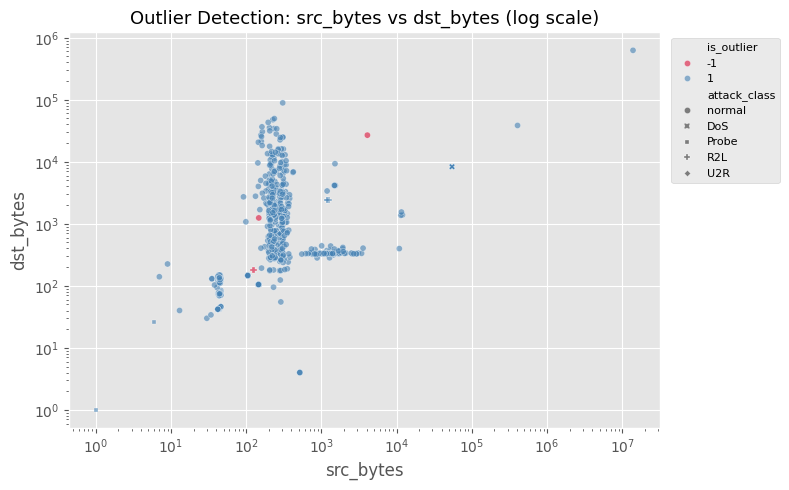

In [5]:
iso = IsolationForest(max_samples="auto", contamination=0.01, random_state=SEED)
df_train["is_outlier"] = iso.fit_predict(df_train[NUMERICAL])

n_outliers = (df_train["is_outlier"] == -1).sum()
print(f"Outliers flagged : {n_outliers:,}  ({n_outliers / len(df_train) * 100:.2f}% of training set)")

# Visualise outliers in src_bytes vs dst_bytes space
plt.figure(figsize=(8, 5))
sample = df_train[::100].copy()
sns.scatterplot(
    data=sample, x="src_bytes", y="dst_bytes",
    hue="is_outlier", style="attack_class",
    palette={1: "steelblue", -1: "crimson"}, alpha=0.6, s=20
)
plt.xscale("log")
plt.yscale("log")
plt.title("Outlier Detection: src_bytes vs dst_bytes (log scale)", fontsize=13)
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## Log-Transform Skewed Features

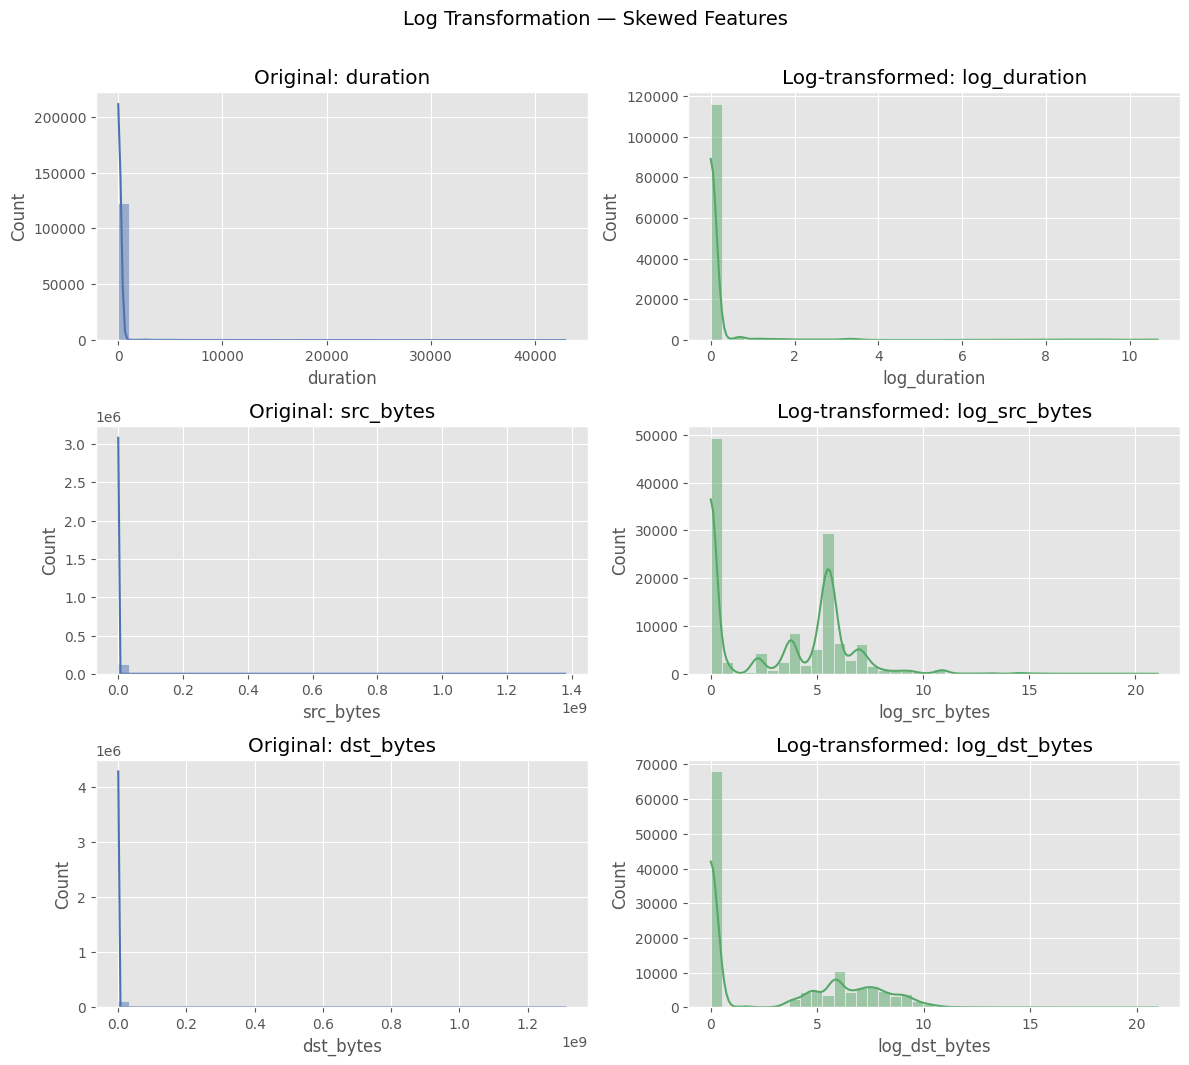

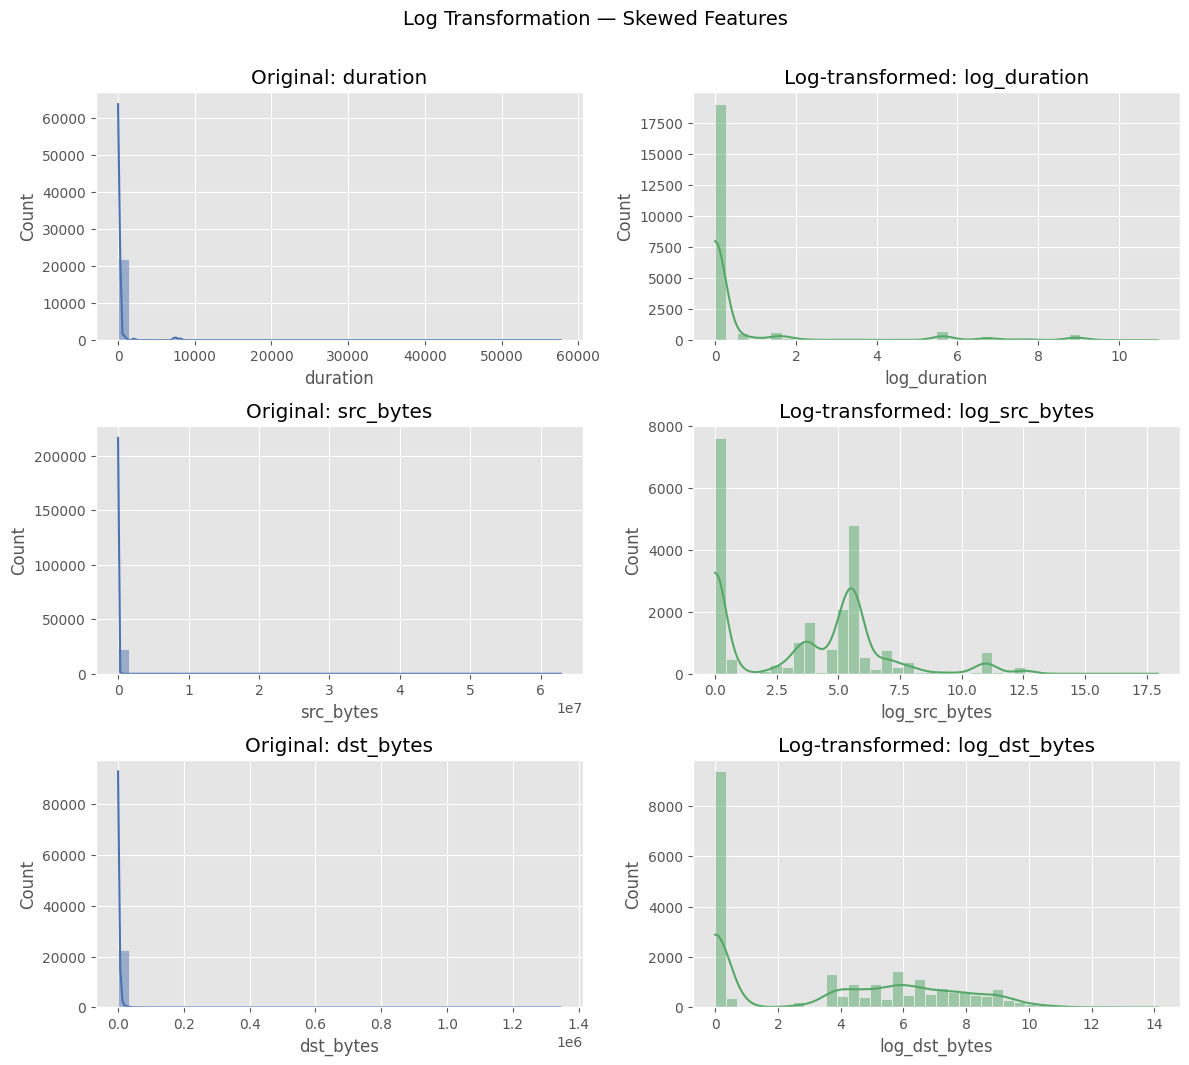

In [6]:
SKEWED_COLS = ["duration", "src_bytes", "dst_bytes"]


def apply_log_transform(df, cols):
    df = df.copy()
    fig, axes = plt.subplots(len(cols), 2, figsize=(12, 3.5 * len(cols)))
    for i, col in enumerate(cols):
        new_col = f"log_{col}"
        df[new_col] = np.log1p(df[col])
        sns.histplot(df[col],     bins=40, kde=True, ax=axes[i][0], color="#4C72B0")
        sns.histplot(df[new_col], bins=40, kde=True, ax=axes[i][1], color="#55A868")
        axes[i][0].set_title(f"Original: {col}")
        axes[i][1].set_title(f"Log-transformed: {new_col}")
    plt.suptitle("Log Transformation — Skewed Features", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
    return df


df_train = apply_log_transform(df_train, SKEWED_COLS)
df_test  = apply_log_transform(df_test,  SKEWED_COLS)

## Feature Engineering

We create 6 new features that capture interaction patterns between existing ones.

In [7]:
def engineer_features(df):
    """Create interaction and derived features."""
    df = df.copy()

    # 1. Total bytes transferred
    df["total_bytes"] = df["src_bytes"] + df["dst_bytes"]

    # 2. Source byte ratio (fraction of total traffic from source)
    df["src_bytes_ratio"] = df["src_bytes"] / (df["total_bytes"] + 1e-5)

    # 3. Packet rate (connections per second; handles zero duration)
    df["packet_rate"] = df["count"] / (df["duration"] + 1e-5)

    # 4. Byte asymmetry
    df["byte_diff"] = np.abs(df["src_bytes"] - df["dst_bytes"])

    # 5. Error flag indicator
    error_flags = ["S0", "S1", "S2", "S3", "REJ"]
    df["is_error_flag"] = df["flag"].isin(error_flags).astype(int)

    # 6. Host service interaction
    df["same_srv_interaction"] = df["same_srv_rate"] * df["dst_host_same_srv_rate"]

    return df


df_train = engineer_features(df_train)
df_test  = engineer_features(df_test)

new_features = ["total_bytes", "src_bytes_ratio", "packet_rate",
                "byte_diff", "is_error_flag", "same_srv_interaction"]
print("New features sample:")
df_train[new_features].head()

New features sample:


,total_bytes,src_bytes_ratio,packet_rate,byte_diff,is_error_flag,same_srv_interaction
0,491,1.000000,200000.0,491,0,0.170
1,146,1.000000,1300000.0,146,0,0.000
2,0,0.000000,12300000.0,0,1,0.005
3,8385,0.027668,500000.0,7921,0,1.000
4,619,0.321486,3000000.0,221,0,1.000


## Encode Categorical Features

- `protocol_type` and `flag` → One-Hot Encoding  
- `service` → Frequency encoding (too many unique values for OHE)

## Feature Engineering Validation

Visualize each new feature's distribution across attack categories to confirm they carry signal.

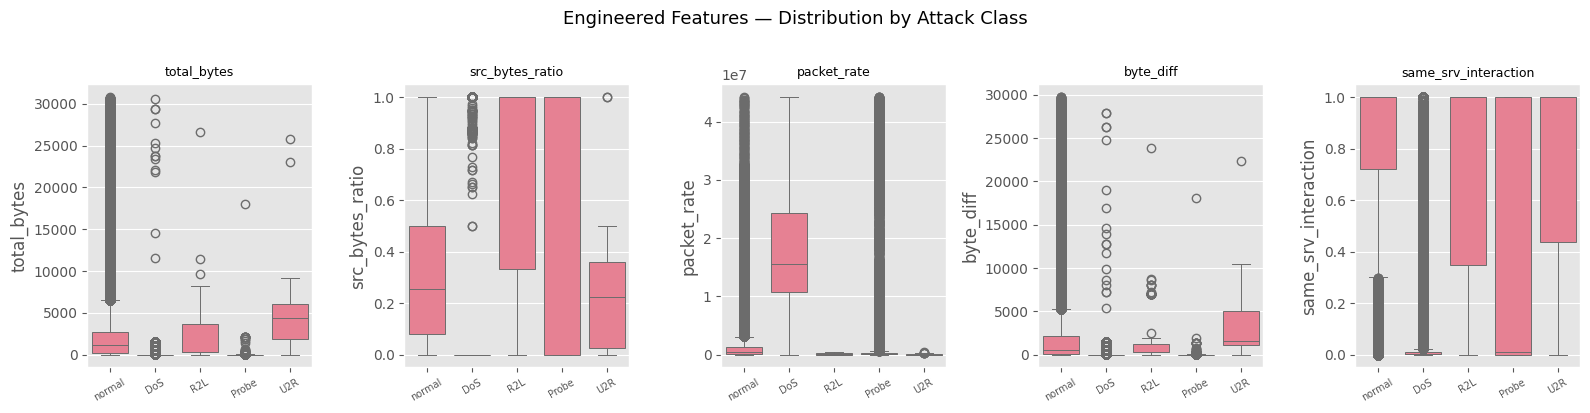

In [8]:
engineered = ['total_bytes', 'src_bytes_ratio', 'packet_rate', 'byte_diff', 'same_srv_interaction']

fig, axes = plt.subplots(1, len(engineered), figsize=(16, 4))
for ax, feat in zip(axes, engineered):
    cap = df_train[feat].quantile(0.98)
    plot_data = df_train[df_train[feat] <= cap][[feat, 'attack_class']].copy()
    sns.boxplot(x='attack_class', y=feat, data=plot_data, ax=ax, linewidth=0.7)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Engineered Features — Distribution by Attack Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# One-Hot Encode protocol_type and flag
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
OHE_COLS = ["protocol_type", "flag"]

ohe_train = pd.DataFrame(
    ohe.fit_transform(df_train[OHE_COLS]),
    columns=ohe.get_feature_names_out(OHE_COLS),
    index=df_train.index
)
ohe_test = pd.DataFrame(
    ohe.transform(df_test[OHE_COLS]),
    columns=ohe.get_feature_names_out(OHE_COLS),
    index=df_test.index
)

# Frequency encode service
service_freq = df_train["service"].value_counts(normalize=True)
df_train["service_freq"] = df_train["service"].map(service_freq)
df_test["service_freq"]  = df_test["service"].map(service_freq).fillna(0)

# Concatenate encoded columns
df_train_enc = pd.concat([df_train, ohe_train], axis=1)
df_test_enc  = pd.concat([df_test,  ohe_test],  axis=1)

# Drop original categorical columns
df_train_enc.drop(columns=["protocol_type", "flag", "service"], inplace=True)
df_test_enc.drop(columns=["protocol_type", "flag", "service"],  inplace=True)

print(f"Encoded training shape : {df_train_enc.shape}")
print(f"OHE columns created    : {list(ohe.get_feature_names_out(OHE_COLS))}")

Encoded training shape : (125973, 66)
OHE columns created    : ['protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'flag_OTH', 'flag_REJ', 'flag_RSTO', 'flag_RSTOS0', 'flag_RSTR', 'flag_S0', 'flag_S1', 'flag_S2', 'flag_S3', 'flag_SF', 'flag_SH']


## Remove Highly Correlated Features

Features with pairwise correlation > 0.95 are removed to reduce redundancy.

In [10]:
corr_matrix = df_train_enc.select_dtypes(include=[np.number]).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]

print(f"Features to drop (correlation > 0.95) : {len(to_drop)}")
for col in to_drop:
    print(f"  - {col}")

df_train_reduced = df_train_enc.drop(columns=to_drop, errors="ignore")
df_test_reduced  = df_test_enc.drop(columns=to_drop,  errors="ignore")

print(f"\nReduced training shape : {df_train_reduced.shape}")

Features to drop (correlation > 0.95) : 10
  - num_root
  - srv_serror_rate
  - srv_rerror_rate
  - dst_host_serror_rate
  - dst_host_srv_serror_rate
  - dst_host_srv_rerror_rate
  - packet_rate
  - byte_diff
  - same_srv_interaction
  - flag_S0

Reduced training shape : (125973, 56)


## Scaling with RobustScaler

RobustScaler is resistant to outliers - ideal here since we have extreme byte values.

## Univariate Feature Ranking

In addition to removing correlated features, we rank remaining features by their mutual information with the target.

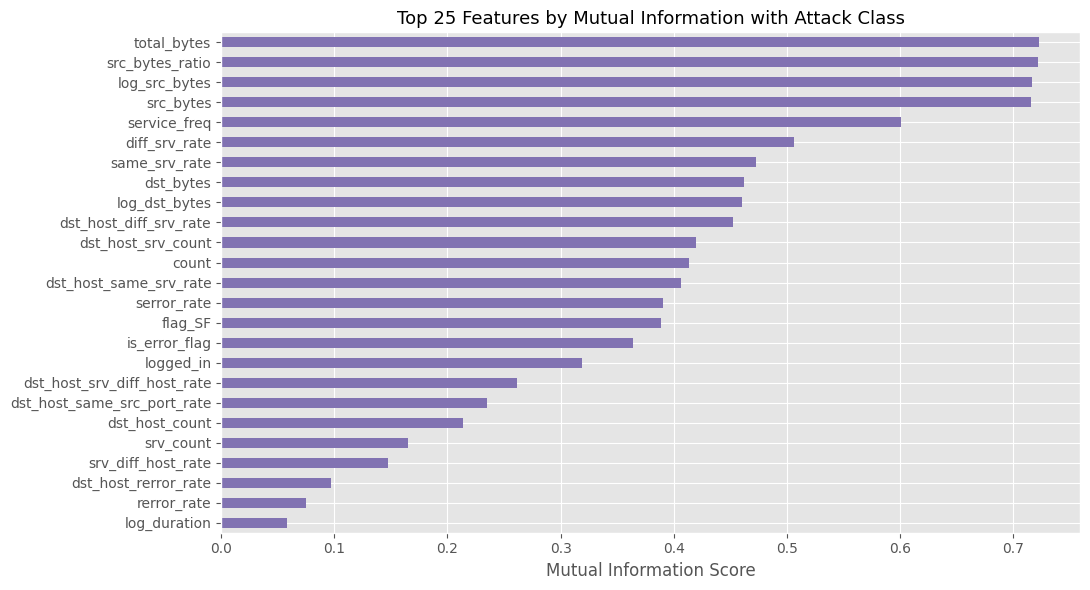

Top 10 most informative features:
total_bytes               0.722671
src_bytes_ratio           0.721472
log_src_bytes             0.716232
src_bytes                 0.715593
service_freq              0.601107
diff_srv_rate             0.506013
same_srv_rate             0.472126
dst_bytes                 0.461627
log_dst_bytes             0.460380
dst_host_diff_srv_rate    0.451910


In [11]:
from sklearn.feature_selection import mutual_info_classif

X_rank = df_train_reduced.drop(columns=['label','attack_class','difficulty_level'], errors='ignore').fillna(0)
y_rank = df_train_reduced['attack_class']

# Select only numeric columns
X_rank = X_rank.select_dtypes(include='number')

mi_scores = mutual_info_classif(X_rank, y_rank, random_state=SEED)
mi_series = pd.Series(mi_scores, index=X_rank.columns).sort_values(ascending=False)

plt.figure(figsize=(11, 6))
mi_series.head(25).sort_values().plot(kind='barh', color='#8172B2')
plt.title('Top 25 Features by Mutual Information with Attack Class', fontsize=13)
plt.xlabel('Mutual Information Score')
plt.tight_layout()
plt.show()

print('Top 10 most informative features:')
print(mi_series.head(10).to_string())

In [12]:
EXCLUDE_FROM_SCALING = ["label", "attack_class", "difficulty_level", "is_outlier"]
features_to_scale = [
    c for c in df_train_reduced.columns
    if c not in EXCLUDE_FROM_SCALING and df_train_reduced[c].dtype in [np.float64, np.int64]
]

scaler = RobustScaler()
df_train_reduced[features_to_scale] = scaler.fit_transform(df_train_reduced[features_to_scale])
df_test_reduced[features_to_scale]  = scaler.transform(df_test_reduced[features_to_scale])

print(f"Scaled {len(features_to_scale)} features with RobustScaler")
print("\nSample stats after scaling (first 5 features):")
df_train_reduced[features_to_scale[:5]].describe().round(3)

Scaled 52 features with RobustScaler

Sample stats after scaling (first 5 features):


,duration,src_bytes,dst_bytes,land,wrong_fragment
count,125973.000,125973.000,125973.000,125973.000,125973.000
mean,287.145,164.937,38.332,0.000,0.023
std,2604.515,21269.316,7793.157,0.014,0.254
min,0.000,-0.159,0.000,0.000,0.000
25%,0.000,-0.159,0.000,0.000,0.000
50%,0.000,0.000,0.000,0.000,0.000
75%,0.000,0.841,1.000,0.000,0.000
max,42908.000,4999869.000,2538638.374,1.000,3.000


## Class Balancing with SMOTE

The dataset is heavily skewed toward DoS and normal traffic. SMOTE synthesises minority class samples.

In [15]:
TARGET_COL = "attack_class"
X = df_train_reduced.drop(columns=["label", "attack_class", "difficulty_level"], errors="ignore").fillna(0)
y = df_train_reduced[TARGET_COL]

print("Class distribution before SMOTE:")
print(y.value_counts())

try:
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(k_neighbors=5, random_state=SEED)
    X_resampled, y_resampled = smote.fit_resample(X, y)
    print("\n SMOTE applied successfully")
except ImportError:
    print("imbalanced-learn not installed — falling back to manual oversampling")
    class_counts = y.value_counts()
    max_count = class_counts.max()
    parts_x, parts_y = [], []
    for cls in class_counts.index:
        x_cls = X[y == cls]
        y_cls = y[y == cls]
        idx = np.random.RandomState(SEED).choice(x_cls.index, size=max_count, replace=True)
        parts_x.append(x_cls.loc[idx])
        parts_y.append(y_cls.loc[idx])
    X_resampled = pd.concat(parts_x).reset_index(drop=True)
    y_resampled = pd.concat(parts_y).reset_index(drop=True)

print("\nClass distribution after resampling:")
print(y_resampled.value_counts().to_string())

Class distribution before SMOTE:
attack_class
normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

 SMOTE applied successfully

Class distribution after resampling:
attack_class
normal    67343
DoS       67343
R2L       67343
Probe     67343
U2R       67343


## 12. PCA Visualisation (Post-SMOTE)

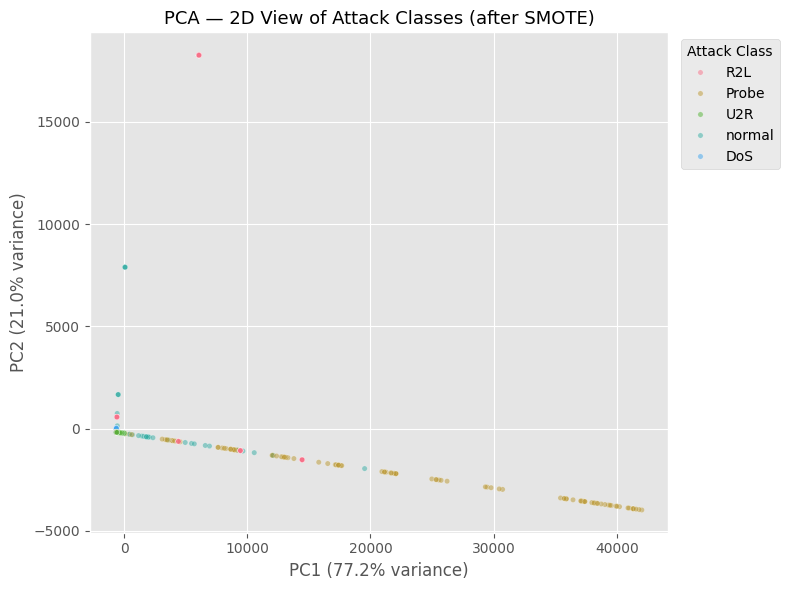

In [16]:
n_plot = min(5000, len(X_resampled))
idx    = X_resampled.sample(n=n_plot, random_state=SEED).index

pca   = PCA(n_components=2)
x_pca = pca.fit_transform(X_resampled.loc[idx])

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=x_pca[:, 0], y=x_pca[:, 1],
    hue=y_resampled.loc[idx], alpha=0.5, s=15
)
plt.title("PCA — 2D View of Attack Classes (after SMOTE)", fontsize=13)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Attack Class", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 12b. Class Balance Verification

Confirm SMOTE produced a balanced dataset and check that resampled feature distributions are sane.

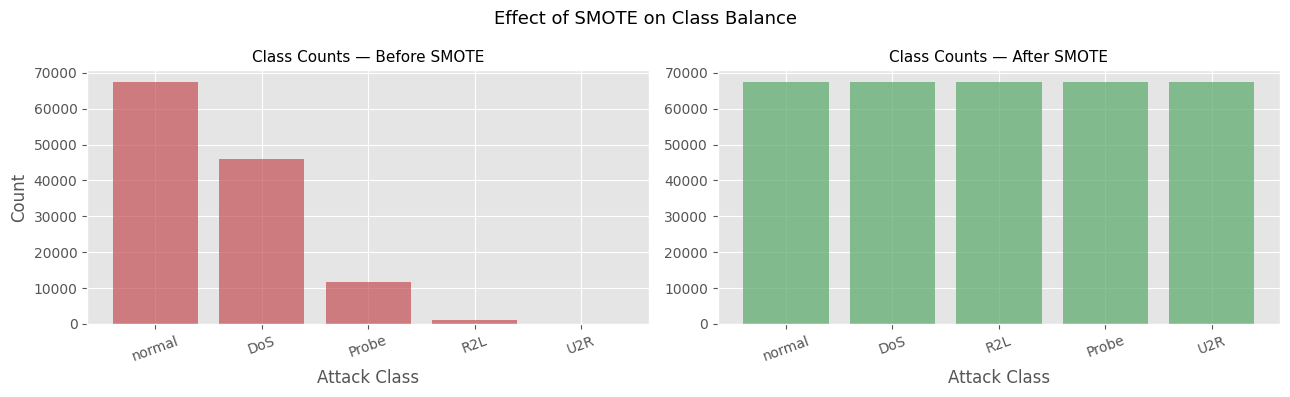

Imbalance ratio before SMOTE : 1295.1x
Imbalance ratio after  SMOTE : 1.0x


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Before vs after class counts
before = df_train['attack_class'].value_counts()
after  = y_resampled.value_counts()

x = range(len(before))
axes[0].bar([str(c) for c in before.index], before.values, color='#C44E52', alpha=0.7, label='Before')
axes[0].set_title('Class Counts — Before SMOTE', fontsize=11)
axes[0].set_xlabel('Attack Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar([str(c) for c in after.index], after.values, color='#55A868', alpha=0.7, label='After')
axes[1].set_title('Class Counts — After SMOTE', fontsize=11)
axes[1].set_xlabel('Attack Class')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Effect of SMOTE on Class Balance', fontsize=13)
plt.tight_layout()
plt.show()

# Imbalance ratio before vs after
ratio_before = before.max() / before.min()
ratio_after  = after.max()  / after.min()
print(f'Imbalance ratio before SMOTE : {ratio_before:.1f}x')
print(f'Imbalance ratio after  SMOTE : {ratio_after:.1f}x')

## 13. Save Processed Dataset

In [20]:
df_final = pd.concat([X_resampled, y_resampled], axis=1)
train_out = os.path.join(PROCESSED_DIR, "train_processed.csv")
df_final.to_csv(train_out, index=False)
joblib.dump(ohe,                    "models/ohe.pkl")
joblib.dump(service_freq.to_dict(), "models/service_freq.pkl")
joblib.dump(scaler,                 "models/scaler.pkl")

print(f"Processed data")

Processed data
